In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WildfireDataset.csv')

/var/folders/6t/2jhf471114v5c23mm3_tc1_r0000gn/T/ipykernel_75239/3600052003.py:1: DtypeWarning: Columns (15: IrwinID) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('WildfireDataset.csv')


In [3]:
df.head()

,Agency,ID_Incident,StartDate,Contained,Controlled,County,FireName,Lat,Long,acres,CauseGeneral,CauseSpecific,CauseSpecificDetail,Department,BadLocation,IrwinID,Shape
0,FD,AEA0A967-E4C9-45C3-BD5F-0000D3C0A9DD,7/17/11 0:00,NaN,NaN,Wichita,Rekindle Krohn Rd,34.091480,-98.898642,0.0,Other causes,Other (remarks required),Unknown (remarks required),Electra VFD,0,NaN,0xE6100000010CF833BC5983B958C0CD1C37A1B50B4140
1,FD,5E7D8AA7-872F-4C28-849C-0001031ACCD5,4/8/20 12:59,4/8/20 13:16,4/8/20 13:52,Aransas,190,28.057600,-97.104200,0.1,Debris and open burning,Hand pile/slash,Unknown (remarks required),Rockport VFD,0,NaN,0xE6100000010C910F7A36AB4658C0E63FA4DFBE0E3C40
2,FD,A9DBA206-FB1E-4061-9500-0001FC0A547D,4/25/09 0:00,NaN,NaN,Bee,Grass Fire,28.413202,-97.723735,0.5,Smoking,Cigar/cigarette/pipe,Unknown (remarks required),Beeville Vol. Fire Dept.,0,NaN,0xE6100000010C000B70AC516E58C07CD43EA1C7693C40
3,FD,E47D6494-9964-4F0A-B4F8-0002615830C7,1/29/08 0:00,NaN,NaN,Bell,7000 Stillman Valley,30.934168,-97.716991,20.0,Debris and open burning,Hand pile/slash,Unknown (remarks required),Florence VFD,0,NaN,0xE6100000010C5002F62CE36D58C0344205A825EF3E40
4,FD,7CD8FF55-5E90-450B-8687-0002A206891B,6/17/08 0:00,NaN,NaN,Mills,Stone Creek #3,31.557167,-98.665667,1.0,Other causes,Other (remarks required),Unknown (remarks required),Mullin Volunteer Fire Department,0,NaN,0xE6100000010C874215489AAA58C01E1F6779A28E3F40


In [4]:
df.shape

(285858, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 285858 entries, 0 to 285857
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Agency               285858 non-null  str    
 1   ID_Incident          285858 non-null  str    
 2   StartDate            285858 non-null  str    
 3   Contained            97945 non-null   str    
 4   Controlled           101968 non-null  str    
 5   County               285858 non-null  str    
 6   FireName             285362 non-null  str    
 7   Lat                  285613 non-null  float64
 8   Long                 285613 non-null  float64
 9   acres                285858 non-null  float64
 10  CauseGeneral         285808 non-null  str    
 11  CauseSpecific        285751 non-null  str    
 12  CauseSpecificDetail  228386 non-null  str    
 13  Department           285858 non-null  str    
 14  BadLocation          285858 non-null  int64  
 15  IrwinID              11056 n

In [6]:
df['BadLocation'].value_counts()

BadLocation
0    282754
1      3104
Name: count, dtype: int64

Text(0, 0.5, 'Count of Fires')

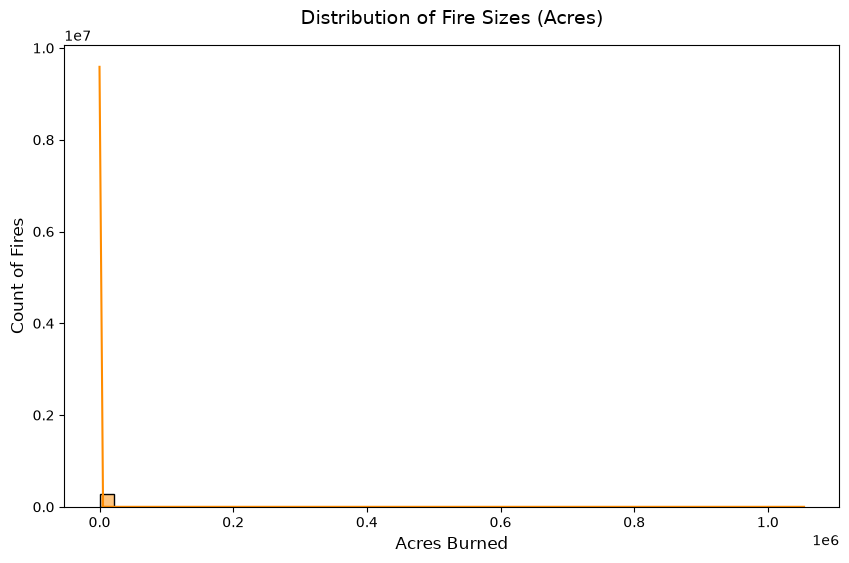

In [8]:
# Target Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='acres', kde=True, color='darkorange', bins=50)

plt.title('Distribution of Fire Sizes (Acres)', fontsize=14, pad=15)
plt.xlabel('Acres Burned', fontsize=12)
plt.ylabel('Count of Fires', fontsize=12)

/Users/tanvirsingh/Data Capstone/venv/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


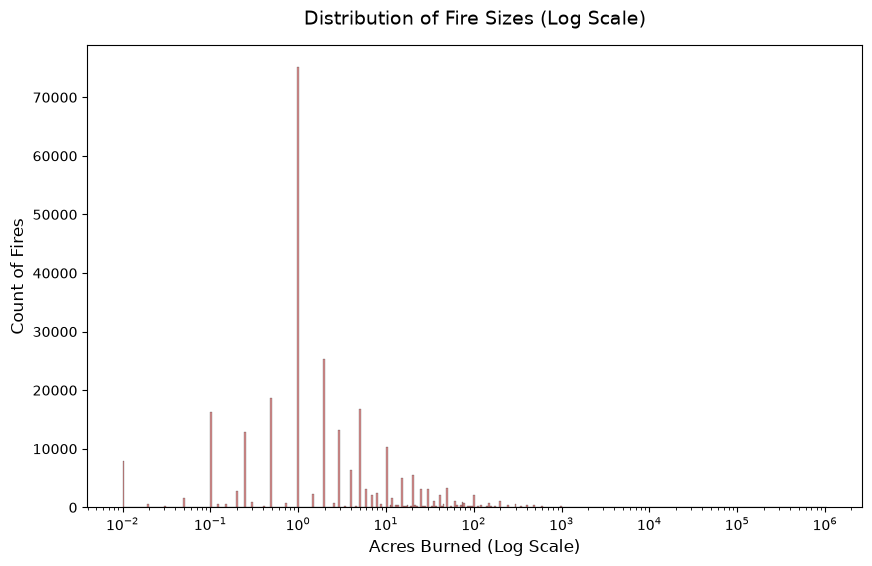

In [9]:
# Log Scale Adjustment to Target

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='acres', kde=True, color='firebrick', log_scale=True)

plt.title('Distribution of Fire Sizes (Log Scale)', fontsize=14, pad=15)
plt.xlabel('Acres Burned (Log Scale)', fontsize=12)
plt.ylabel('Count of Fires', fontsize=12)

plt.show()

In [8]:
df['StartDate'] = pd.to_datetime(df['StartDate'])

/var/folders/6t/2jhf471114v5c23mm3_tc1_r0000gn/T/ipykernel_74830/748065729.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['StartDate'] = pd.to_datetime(df['StartDate'])


In [9]:
time_span_days = (df['StartDate'].max() - df['StartDate'].min()).days
years_collected = time_span_days / 365.25

print(f"The dataset spans {years_collected:.2f} years.")

The dataset spans 41.70 years.


In [10]:
earliest_date = df['StartDate'].min()
latest_date = df['StartDate'].max()
print(f"Earliest Date: {earliest_date}")
print(f"Latest Date:   {latest_date}")

Earliest Date: 1985-01-01 00:00:00
Latest Date:   2026-09-14 11:47:00


In [11]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [Agency, ID_Incident, StartDate, Contained, Controlled, County, FireName, Lat, Long, acres, CauseGeneral, CauseSpecific, CauseSpecificDetail, Department, BadLocation, IrwinID, Shape]
Index: []


### Info For Slide 6:
- Dataset has 285858 observations and 17 features
- Focussing on acreage as our target variable
- Feature Types:
    - Agency, ID_Incident, StartDate, Contained, Controlled, County, FireName, CauseGeneral, CauseSpecific, CauseSpecificDetail, Department, IrwinID, and Shape - Categorical
    - Lat/Long - Spatial Features
    - acres - Numerical float
    - BadLocation - Binary categorical
- Dataset contains many records of almost 300,000
- Low dimensional data with only 17 features
- Dataset spans over 41 years (1985 - 2026)
- We will measure the amount of acres a fire would probably burn through as a baseline
- BadLocation contains class imbalance (0 - 282754, 1 - 3104)
- acres feature is very heavily right skewed
- Some features have too many null observations to be used (IrwinID - 96% null)
- The Shape feature has unknown use to us and contains a bunch of numbers and letters
- Majority of features contain some missing values but not much to be considered useless
- Features without any missing values are Agency, ID_Incident, StartDate, County, acres, Department, BadLocation, and Shape
- No exact duplicate rows

